In [1]:
import pandas as pd
import matplotlib.pyplot as plt

- **Seaborn** *geyser* dataset will be used to show regression imputation

In [2]:
import seaborn as sns

- **Scikit-learn** linear model will be used for regression imputation

In [3]:
from sklearn import linear_model

- The *carsales* DataFrame will be modified with missing values

In [4]:
cardata = { "Mercedes": [2, 4, None, 4, 0, 3],
           "Ford": [3, 0, 0, 1, 6, 12],
           "Tata":[9, 3, 4, 1, 0, 0],
           "Renault":[12, 1, None, None, 3, 1],
          }
carsalesMv = pd.DataFrame(cardata)
carsalesMv.index.rename("Sales place", inplace=True)
carsalesMv.rename(index={0: "One",
                          1: "Two",
                          2: "Three",
                          3: "Four",
                          4: "Five",
                          5: "Six"},
                   inplace=True)
carsalesMv

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,2.0,3,9,12.0
Two,4.0,0,3,1.0
Three,NaN,0,4,NaN
Four,4.0,1,1,NaN
Five,0.0,6,0,3.0
Six,3.0,12,0,1.0


# Descriptive statistics for missing values

In [5]:
carsalesMv.isnull()

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,False,False,False,False
Two,False,False,False,False
Three,True,False,False,True
Four,False,False,False,True
Five,False,False,False,False
Six,False,False,False,False


## Statistics over missing values per column

In [6]:
carsalesMv.isnull().sum()

Mercedes    1
Ford        0
Tata        0
Renault     2
dtype: int64

# Descriptive statistics without missing values

For some standard functions missing values are dropped on a *per-column* basis by default

In [7]:
carsalesMv.describe()

,Mercedes,Ford,Tata,Renault
count,5.00000,6.000000,6.000000,4.000000
mean,2.60000,3.666667,2.833333,4.250000
std,1.67332,4.676181,3.430258,5.251984
min,0.00000,0.000000,0.000000,1.000000
25%,2.00000,0.250000,0.250000,1.000000
50%,3.00000,2.000000,2.000000,2.000000
75%,4.00000,5.250000,3.750000,5.250000
max,4.00000,12.000000,9.000000,12.000000


The `.describe()` 's *count* row shows that the *NaN* values were dropped for some columns

# Drop missing values

Either by rows or columns.<br>
We drop entire rows or columns if a missing value exists.

In [8]:
carsalesMv

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,2.0,3,9,12.0
Two,4.0,0,3,1.0
Three,NaN,0,4,NaN
Four,4.0,1,1,NaN
Five,0.0,6,0,3.0
Six,3.0,12,0,1.0


In [9]:
carsalesMv.dropna()

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,2.0,3,9,12.0
Two,4.0,0,3,1.0
Five,0.0,6,0,3.0
Six,3.0,12,0,1.0


In [10]:
carsalesMv.dropna(axis=1)

,Ford,Tata
Sales place,,
One,3,9
Two,0,3
Three,0,4
Four,1,1
Five,6,0
Six,12,0


# Imputation

## Zeroes to replace the missing values

In [11]:
carsalesMv.fillna(0, inplace=False)

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,2.0,3,9,12.0
Two,4.0,0,3,1.0
Three,0.0,0,4,0.0
Four,4.0,1,1,0.0
Five,0.0,6,0,3.0
Six,3.0,12,0,1.0


## Means to replace the missing values

Pandas' `.mean()` doesn't include null values in its calculation

In [12]:
carsalesMean = carsalesMv.mean()
carsalesMv.fillna(carsalesMean, inplace=False)

,Mercedes,Ford,Tata,Renault
Sales place,,,,
One,2.0,3,9,12.00
Two,4.0,0,3,1.00
Three,2.6,0,4,4.25
Four,4.0,1,1,4.25
Five,0.0,6,0,3.00
Six,3.0,12,0,1.00


## Regression imputation

- Load the geyser dataset from Seaborn and make a copy of it.

In [13]:
geyser = sns.load_dataset("geyser")
geyser2 = geyser.copy(deep=True)
geyser2

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long
...,...,...,...
267,4.117,81,long
268,2.150,46,short
269,4.417,90,long
270,1.817,46,short


- Design some missing values in the geyser data

In [14]:
nlist1 =[4, 34, 35, 36, 67, 89, 94, 192, 204]
nlist2 = [5, 22, 73, 154, 264]

for n in nlist1:
    geyser2.loc[n, "duration"] = None

for n in nlist2:
    geyser2.loc[n, "waiting"] = None

geyser2

,duration,waiting,kind
0,3.600,79.0,long
1,1.800,54.0,short
2,3.333,74.0,long
3,2.283,62.0,short
4,NaN,85.0,long
...,...,...,...
267,4.117,81.0,long
268,2.150,46.0,short
269,4.417,90.0,long
270,1.817,46.0,short


In [15]:
geyser2.isnull().sum()

duration    9
waiting     5
kind        0
dtype: int64

In [16]:
geyser3 = geyser2.copy(deep=True)

### Simple model-based imputation

Pandas' **linear interpolation** function is used to impute values according to some simple interpolation model algorythm 

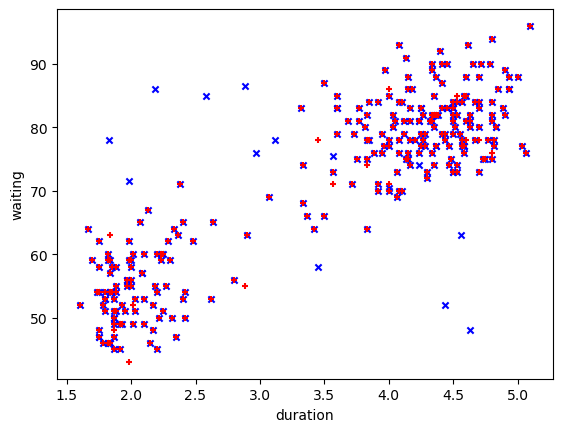

In [17]:
geyser2["duration"].interpolate(method="linear", inplace=True)
geyser2["waiting"].interpolate(method="linear", inplace=True)

fig, ax = plt.subplots()
geyser2.plot.scatter(x="duration", y="waiting", color="Blue", marker="x", ax=ax)
geyser.plot.scatter(x="duration", y="waiting", color="Red", marker="+", ax=ax)
plt.show()

As can be seen from this plot, click-n-forget imputation with models may cause arbitrary results.<br>
Careful study of the data is needed for useful imputation.

### Dual simple regression model

- Create a **scikit-learn linear model** on a DataFrame without missing values (DataFrame has dropped the missing values)
- Train each one of them on one *input* variable and one *target* variable

In [18]:
geyser4Dmv = geyser3.dropna()
model1 = linear_model.LinearRegression()
model2 = linear_model.LinearRegression()
model1.fit(X=geyser4Dmv[["duration"]], y=geyser4Dmv["waiting"])
model2.fit(X=geyser4Dmv[["waiting"]], y=geyser4Dmv["duration"])

LinearRegression()

Some limitations in scikit-learn's linear model create a need for modifying the *null* values, <br>
or for making sub-selections of *isnotnull* values.<br>
Here we modify the *null* values by setting them to extreme values.

In [19]:
geyser3["waiting"].fillna(10000, inplace=True)
geyser3["duration"].fillna(10000, inplace=True)
geyser3["estDuration"] = model2.predict(geyser3[["waiting"]])
geyser3["estWaiting"] = model1.predict(geyser3[["duration"]])
geyser3

,duration,waiting,kind,estDuration,estWaiting
0,3.600,79.0,long,4.096761,72.203012
1,1.800,54.0,short,2.195578,52.894811
2,3.333,74.0,long,3.716524,69.338962
3,2.283,62.0,short,2.803957,58.075845
4,10000.000,85.0,long,4.553044,107301.370115
...,...,...,...,...,...
267,4.117,81.0,long,4.248855,77.748757
268,2.150,46.0,short,1.587200,56.649184
269,4.417,90.0,long,4.933281,80.966790
270,1.817,46.0,short,1.587200,53.077166


Replace the extreme values with estimated values, which is *imputation*

In [20]:
geyser3.loc[geyser3["duration"] > 5000, "duration"] = geyser3["estDuration"]
geyser3.loc[geyser3["waiting"] > 5000, "waiting"] = geyser3["estWaiting"]
geyser3

,duration,waiting,kind,estDuration,estWaiting
0,3.600000,79.0,long,4.096761,72.203012
1,1.800000,54.0,short,2.195578,52.894811
2,3.333000,74.0,long,3.716524,69.338962
3,2.283000,62.0,short,2.803957,58.075845
4,4.553044,85.0,long,4.553044,107301.370115
...,...,...,...,...,...
267,4.117000,81.0,long,4.248855,77.748757
268,2.150000,46.0,short,1.587200,56.649184
269,4.417000,90.0,long,4.933281,80.966790
270,1.817000,46.0,short,1.587200,53.077166


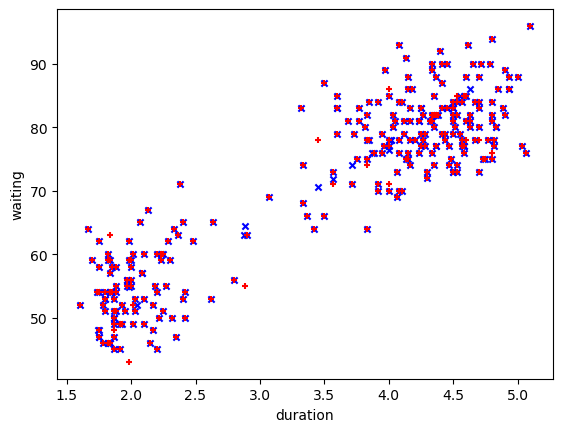

In [21]:
fig, ax = plt.subplots()
geyser3.plot.scatter(x="duration", y="waiting", color="Blue", marker="x", ax=ax)
geyser.plot.scatter(x="duration", y="waiting", color="Red", marker="+", ax=ax)
plt.show()